✅ All libraries imported successfully!
Shape: (200, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   42.035000           61.105000               51.165000
std     57.879185   14.636424           25.286777               19.237416
min      1.000000   18.000000           15.000000                3.000000
25%     50.750000   29.750000           41.500000   

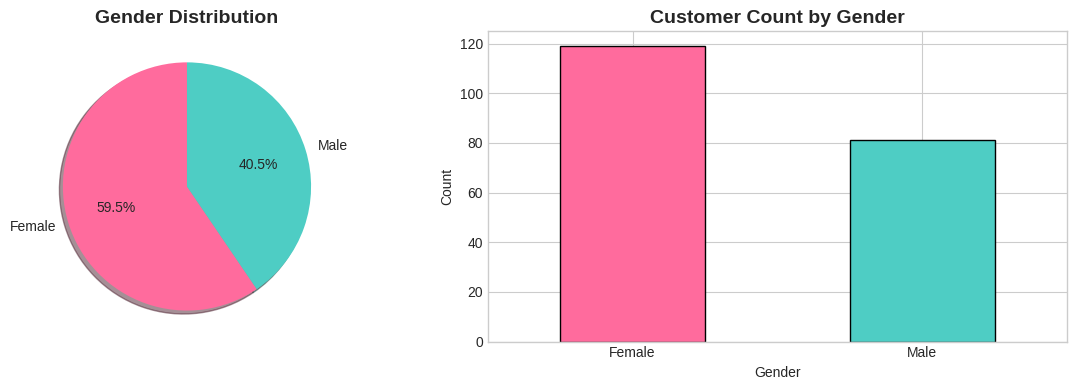

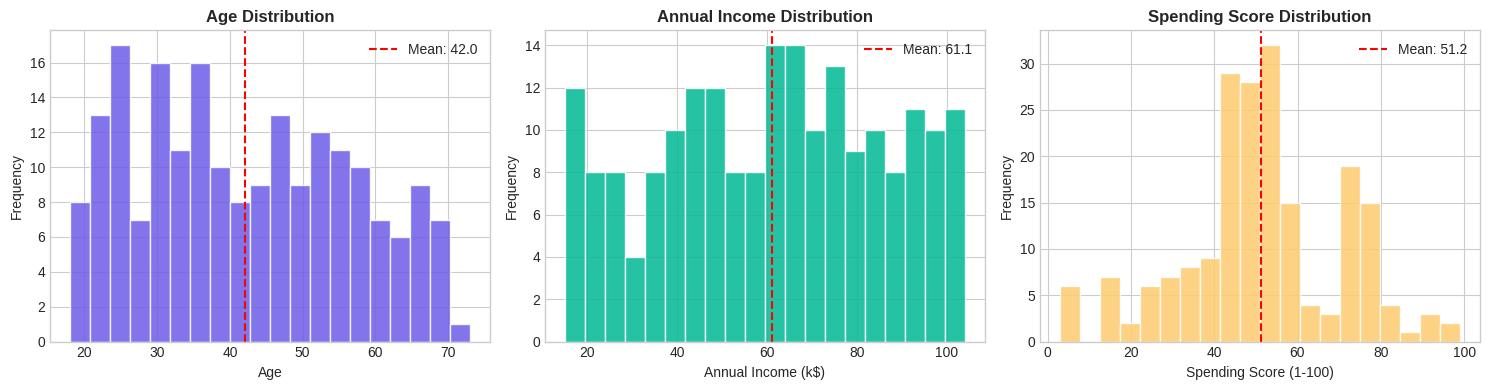

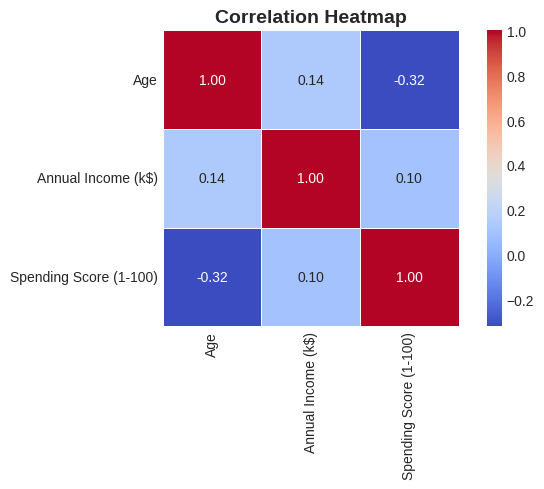

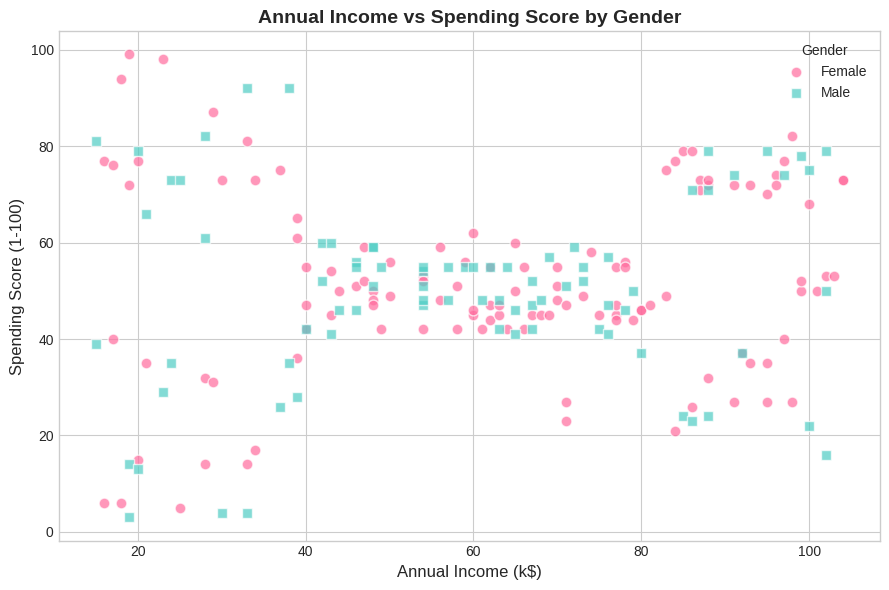

Original shape: (200, 2)
Scaled sample:
 [[-1.828 -0.634]
 [-1.828  1.555]
 [-1.788 -2.354]
 [-1.788  1.346]
 [-1.749 -0.582]]

✅ Scaling done!


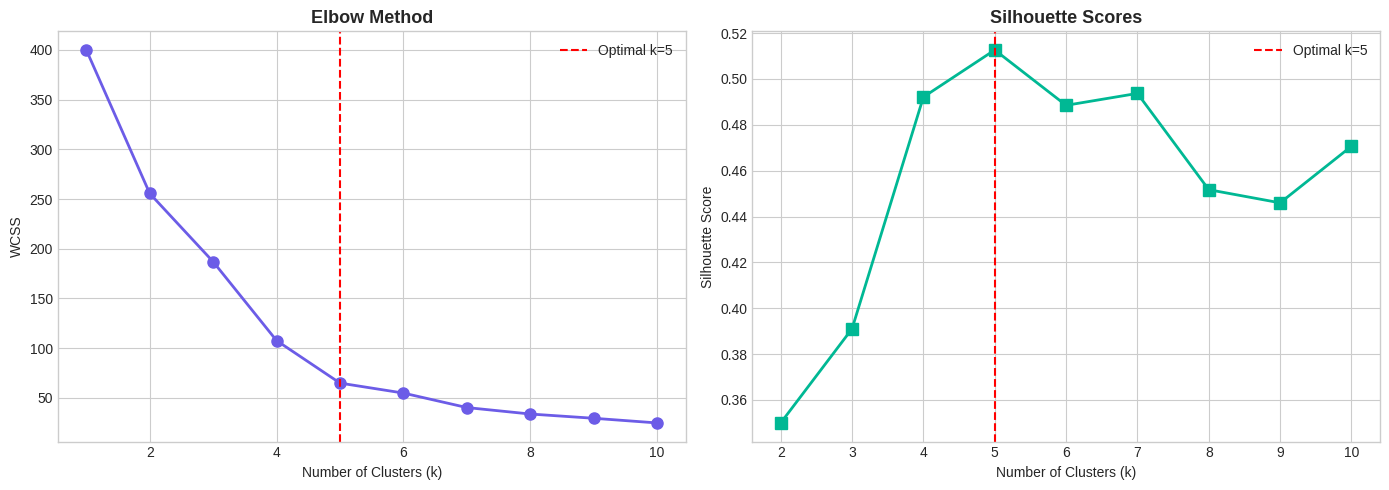

✅ Best Silhouette Score: 0.513
Cluster Distribution:
Cluster
0    89
1    27
2    22
3    39
4    23
Name: count, dtype: int64

Silhouette Score: 0.513


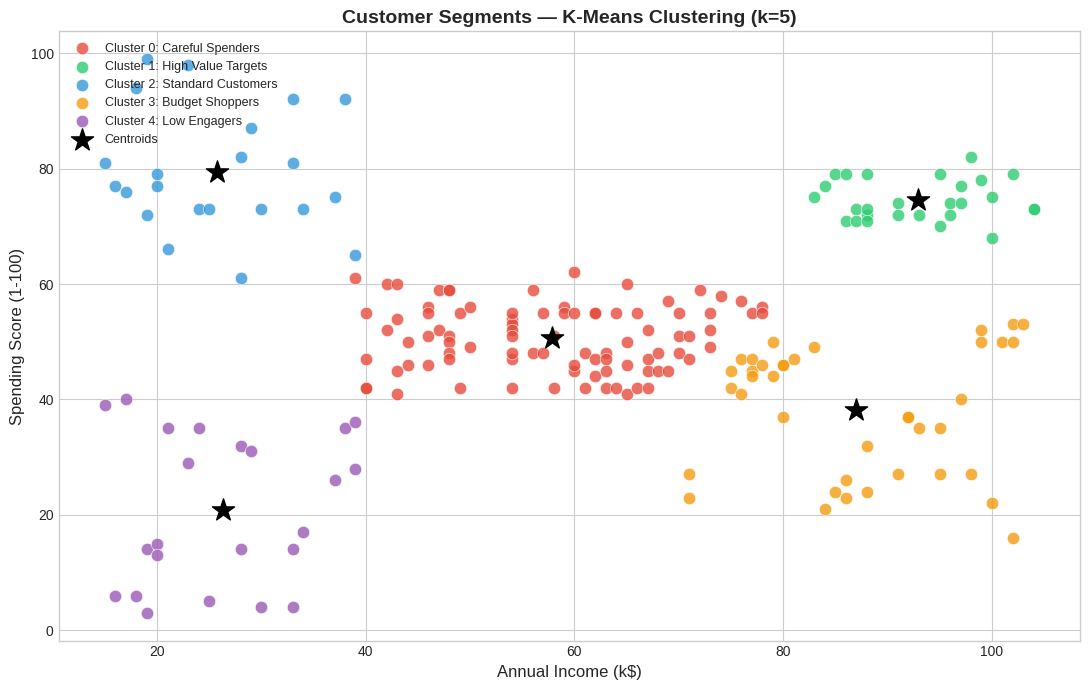

          Age  Annual Income (k$)  Spending Score (1-100)  Count
Cluster                                                         
0        45.4                57.9                    50.6     89
1        40.7                92.9                    74.5     27
2        25.3                25.7                    79.4     22
3        42.8                87.0                    38.1     39
4        45.2                26.3                    20.9     23
       CUSTOMER SEGMENTATION — BUSINESS INSIGHTS

Cluster 0: Careful Spenders
  Profile  : High Income, Low Spending
  Count    : 89 customers
  Strategy : Offer premium loyalty rewards

Cluster 1: High Value Targets
  Profile  : High Income, High Spending
  Count    : 27 customers
  Strategy : Priority marketing — highest ROI

Cluster 2: Standard Customers
  Profile  : Average Income & Spending
  Count    : 22 customers
  Strategy : Discounts and engagement campaigns

Cluster 3: Budget Shoppers
  Profile  : Low Income, High Spending
  Cou

In [2]:
# Cell 1 - Markdown
# 🛍️ Customer Segmentation using K-Means Clustering
# Internship Mini Project
# Cell 2 - Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

print('✅ All libraries imported successfully!')
# Cell 3 - Load Dataset
df = pd.read_csv('Mall_Customers.csv')
print('Shape:', df.shape)
df.head()
# Cell 4 - Basic Info
print(df.info())
print(df.describe())
print("\nMissing Values:\n", df.isnull().sum())
# Cell 5 - Gender Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

gender_counts = df['Genre'].value_counts()
colors = ['#FF6B9D', '#4ECDC4']

axes[0].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, shadow=True)
axes[0].set_title('Gender Distribution', fontsize=14, fontweight='bold')

gender_counts.plot(kind='bar', ax=axes[1], color=colors, edgecolor='black', width=0.5)
axes[1].set_title('Customer Count by Gender', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()
# Cell 6 - Feature Distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
colors_hist = ['#6C5CE7', '#00B894', '#FDCB6E']
titles = ['Age Distribution', 'Annual Income Distribution', 'Spending Score Distribution']

for ax, feature, color, title in zip(axes, features, colors_hist, titles):
    ax.hist(df[feature], bins=20, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(df[feature].mean(), color='red', linestyle='--', linewidth=1.5,
               label=f'Mean: {df[feature].mean():.1f}')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(feature)
    ax.set_ylabel('Frequency')
    ax.legend()

plt.tight_layout()
plt.show()
# Cell 7 - Correlation Heatmap
plt.figure(figsize=(7, 5))
numeric_df = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
corr = numeric_df.corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
# Cell 8 - Scatter Plot: Income vs Spending by Gender
plt.figure(figsize=(9, 6))

for gender, color, marker in zip(['Female', 'Male'], ['#FF6B9D', '#4ECDC4'], ['o', 's']):
    subset = df[df['Genre'] == gender]
    plt.scatter(subset['Annual Income (k$)'], subset['Spending Score (1-100)'],
                c=color, label=gender, alpha=0.7, s=60, marker=marker, edgecolors='white')

plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)
plt.title('Annual Income vs Spending Score by Gender', fontsize=14, fontweight='bold')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()
# Cell 9 - Feature Scaling
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Original shape:', X.shape)
print('Scaled sample:\n', X_scaled[:5].round(3))
print('\n✅ Scaling done!')
# Cell 10 - Elbow Method + Silhouette Score
wcss = []
silhouette_scores = []
K_range = range(2, 11)

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', max_iter=300, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', max_iter=300, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, 11), wcss, 'bo-', linewidth=2, markersize=8, color='#6C5CE7')
axes[0].axvline(x=5, color='red', linestyle='--', linewidth=1.5, label='Optimal k=5')
axes[0].set_title('Elbow Method', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('WCSS')
axes[0].legend()

axes[1].plot(list(K_range), silhouette_scores, 's-', linewidth=2, markersize=8, color='#00B894')
axes[1].axvline(x=5, color='red', linestyle='--', linewidth=1.5, label='Optimal k=5')
axes[1].set_title('Silhouette Scores', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'✅ Best Silhouette Score: {max(silhouette_scores):.3f}')
# Cell 11 - Apply K-Means (k=5)
kmeans = KMeans(n_clusters=5, init='k-means++', max_iter=300, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print('Cluster Distribution:')
print(df['Cluster'].value_counts().sort_index())
print(f'\nSilhouette Score: {silhouette_score(X_scaled, df["Cluster"]):.3f}')
# Cell 12 - Visualize Clusters
colors = ['#E74C3C', '#2ECC71', '#3498DB', '#F39C12', '#9B59B6']
cluster_names = [
    'Cluster 0: Careful Spenders',
    'Cluster 1: High Value Targets',
    'Cluster 2: Standard Customers',
    'Cluster 3: Budget Shoppers',
    'Cluster 4: Low Engagers'
]

plt.figure(figsize=(11, 7))

for i in range(5):
    cluster_data = df[df['Cluster'] == i]
    plt.scatter(cluster_data['Annual Income (k$)'],
                cluster_data['Spending Score (1-100)'],
                s=80, c=colors[i], label=cluster_names[i],
                alpha=0.8, edgecolors='white', linewidth=0.5)

centroids_original = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centroids_original[:, 0], centroids_original[:, 1],
            s=280, c='black', marker='*', zorder=5, label='Centroids')

plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)
plt.title('Customer Segments — K-Means Clustering (k=5)', fontsize=14, fontweight='bold')
plt.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()
# Cell 13 - Cluster Profiles
profile = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean().round(1)
profile['Count'] = df['Cluster'].value_counts().sort_index()
print(profile)
# Cell 14 - Business Insights
insights = {
    0: ('Careful Spenders',   'High Income, Low Spending',   'Offer premium loyalty rewards'),
    1: ('High Value Targets', 'High Income, High Spending',  'Priority marketing — highest ROI'),
    2: ('Standard Customers', 'Average Income & Spending',   'Discounts and engagement campaigns'),
    3: ('Budget Shoppers',    'Low Income, High Spending',   'EMI / Buy-now-pay-later options'),
    4: ('Low Engagers',       'Low Income, Low Spending',    'Re-engage with low-cost promotions'),
}

print('=' * 60)
print('       CUSTOMER SEGMENTATION — BUSINESS INSIGHTS')
print('=' * 60)
for cluster, (name, profile_str, strategy) in insights.items():
    count = len(df[df['Cluster'] == cluster])
    print(f'\nCluster {cluster}: {name}')
    print(f'  Profile  : {profile_str}')
    print(f'  Count    : {count} customers')
    print(f'  Strategy : {strategy}')
print('=' * 60)
# Cell 15 - Save Output
df.to_csv('Customer_Segments_Output.csv', index=False)
print('✅ Saved to Customer_Segments_Output.csv')
print(df.head())